# Extreme Gradient Boosting (XGBoost) com Mixture of Experts (MoE)

Nesse notebook iremos treinar modelos XGBoost em uma arquitetura experimental de MoE e iremos comparar seus resultados com os modelos treinados até aqui.

## Importando as Bibliotecas

Primeiro, vamos importar nossas bibliotecas.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Carregando o Dataset

Agora, vamos carregar o dataset.

In [2]:
df = pd.read_parquet("../../data/processed/03_processed.parquet")

In [3]:
df = df.convert_dtypes()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   tipo_imovel                       7919 non-null   string  
 1   preco                             7919 non-null   Int64   
 2   condominio                        4602 non-null   Int64   
 3   area_m2                           7919 non-null   Int64   
 4   quartos                           7918 non-null   Int64   
 5   banheiros                         7918 non-null   Int64   
 6   vagas                             7286 non-null   Int64   
 7   piscina                           7919 non-null   boolean 
 8   espaco_gourmet                    7919 non-null   boolean 
 9   academia                          7919 non-null   boolean 
 10  spa_massagem                      7919 non-null   boolean 
 11  espaco_lazer                      7919 non-null   boolean 
 12  are

In [5]:
df.head(10)

,tipo_imovel,preco,condominio,area_m2,quartos,banheiros,vagas,piscina,espaco_gourmet,academia,...,distancia_aeroporto_km,faixa_area,faixa_condominio,m2_por_banheiro,m2_por_quarto,banheiros_por_m2,quartos_por_m2,banheiro_por_quarto,quarto_por_vaga,cluster
0,apartamento,350000,720,60,2,2,1,True,True,True,...,16.213545,pequeno,medio,30.0,30.0,0.033333,0.033333,1.0,2.0,4
1,apartamento,511914,<NA>,37,1,1,1,True,True,True,...,7.250204,pequeno,NaN,37.0,37.0,0.027027,0.027027,1.0,1.0,1
2,apartamento,980000,1037,125,3,5,2,True,True,False,...,8.381749,medio,alto,25.0,41.666667,0.04,0.024,1.666667,1.5,1
3,apartamento,2799000,1200,244,3,4,4,True,True,True,...,8.824588,grande,alto,61.0,81.333333,0.016393,0.012295,1.333333,0.75,14
4,apartamento,370000,460,57,2,2,1,True,True,True,...,9.267687,pequeno,medio,28.5,28.5,0.035088,0.035088,1.0,2.0,11
5,apartamento,499000,<NA>,55,2,2,1,True,True,True,...,4.911235,pequeno,NaN,27.5,27.5,0.036364,0.036364,1.0,2.0,7
6,apartamento,195000,350,52,1,1,<NA>,True,True,True,...,9.094186,pequeno,baixo,52.0,52.0,0.019231,0.019231,1.0,<NA>,8
7,apartamento,1210314,<NA>,128,3,3,2,True,True,True,...,6.613218,medio,NaN,42.666667,42.666667,0.023438,0.023438,1.0,1.5,1
8,apartamento,860000,880,105,3,4,2,True,True,True,...,7.747091,medio,alto,26.25,35.0,0.038095,0.028571,1.333333,1.5,1
9,apartamento,400000,400,55,2,2,1,True,True,True,...,3.412207,pequeno,baixo,27.5,27.5,0.036364,0.036364,1.0,2.0,7


## Divisão Treino-Teste

Nessa etapa de modelagem faremos otimização de hiperparâmetros dos nossos modelos e para checarmos a qualidade final do modelo iremos testâ-lo em dados de teste. Para isso precisamos dividir os dados de treinamento e de teste.

In [6]:
df["group"] = (df["preco"] > 1_000_000)

In [7]:
from sklearn.model_selection import train_test_split
from utils import random_state

X = df.drop("preco", axis="columns")
y = df["preco"]

X_normal = X[X["group"] == False].drop("group", axis="columns")
X_premium = X[X["group"] == True].drop("group", axis="columns")

y_normal = y[X["group"] == False]
y_premium = y[X["group"] == True]

X = X.drop("group", axis="columns")

X_train_normal, X_test_normal, y_train_normal, y_test_normal = train_test_split(
    X_normal,
    y_normal,
    train_size=0.8,
    random_state=random_state,
)

X_train_premium, X_test_premium, y_train_premium, y_test_premium = train_test_split(
    X_premium,
    y_premium,
    train_size=0.8,
    random_state=random_state,
)

/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Modelagem

O primeiro modelo que iremos treinar será o nosso baseline, uma regressão linear múltipla. Vamos inicialmente separar as features do nosso dataset baseado nos tipos delas.

In [8]:
discrete_columns = ["quartos", "banheiros", "vagas"]

continuous_columns = (X
    .drop(discrete_columns, axis="columns")
    .select_dtypes(include=["Int64", "Float64"])
    .columns
    .to_list()
)

ordinal_columns = (X
    .select_dtypes(include=["category"])
    .columns
    .to_list()
)

categorical_columns = (X
    .select_dtypes(include="string")
    .columns
    .to_list()
)

boolean_columns = (X
    .select_dtypes(include="boolean")
    .columns
    .to_list()
)

Agora, vamos montar o nosso pipeline de treinamento para a regressão linear.

In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
)
from sklearn.pipeline import Pipeline

from feature_engine.transformation import (
    LogCpTransformer,
    YeoJohnsonTransformer,
)

from xgboost import XGBRegressor

def get_xgboost_pipeline(parameters):
    imputer = SimpleImputer(strategy="median")
    imputer.set_output(transform="pandas")

    discrete_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    continuous_pipeline = Pipeline(steps=[
        ("imputer", imputer),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])


    boolean_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("continuous", continuous_pipeline, continuous_columns),
            ("discrete", discrete_pipeline, discrete_columns),
            ("categorical", categorical_pipeline, categorical_columns),
            ("ordinal", ordinal_pipeline, ordinal_columns),
            ("boolean", boolean_pipeline, boolean_columns),
        ],
        remainder="drop",
    )

    regressor = XGBRegressor(
        n_estimators=parameters["n_estimators"],
        max_depth=parameters["max_depth"],
        learning_rate=parameters["learning_rate"],
        min_child_weight=parameters["min_child_weight"],
        subsample=parameters["subsample"],
        colsample_bytree=parameters["colsample_bytree"],
        reg_alpha=parameters["reg_alpha"],
        reg_lambda=parameters["reg_lambda"],
        random_state=random_state,
    )

    # transformer = QuantileTransformer(
    #     output_distribution="normal",
    #     random_state=random_state,
    # )

    # model = TransformedTargetRegressor(
    #     regressor=regressor,
    #     transformer=transformer,
    # )

    model = regressor

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    return pipeline

def get_xgboost_parameters(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000, step=100),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1e-1, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1e1, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 1e2, log=True),
    }

## Treinamento no Grupo `normal`

Vamos fazer o treinamento no grupo de imóveis `normais`

In [10]:
import utils

study = utils.get_study(
    get_pipeline=get_xgboost_pipeline,
    get_parameters=get_xgboost_parameters,
    X_train=X_train_normal,
    y_train=y_train_normal,
    n_trials=20
)

[I 2026-08-24 22:32:21,654] A new study created in memory with name: no-name-d5164288-7c91-4fa8-81cf-6c526d7420cd
Best trial: 0. Best value: -114466:   5%|▌         | 1/20 [00:05<01:52,  5.90s/it]

[I 2026-08-24 22:32:27,551] Trial 0 finished with value: -114465.875 and parameters: {'n_estimators': 1900, 'max_depth': 2, 'learning_rate': 0.005401732518896231, 'min_child_weight': 1, 'subsample': 0.7245982564446397, 'colsample_bytree': 0.8635702601484998, 'reg_alpha': 1.954530011375315e-08, 'reg_lambda': 0.007343237456624558}. Best is trial 0 with value: -114465.875.


Best trial: 1. Best value: -97290.6:  10%|█         | 2/20 [00:12<01:54,  6.38s/it]

[I 2026-08-24 22:32:34,274] Trial 1 finished with value: -97290.5640625 and parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.0652267214580424, 'min_child_weight': 5, 'subsample': 0.7138069137294848, 'colsample_bytree': 0.734023112481042, 'reg_alpha': 0.5877440499775096, 'reg_lambda': 17.068717969827876}. Best is trial 1 with value: -97290.5640625.


Best trial: 1. Best value: -97290.6:  15%|█▌        | 3/20 [00:15<01:18,  4.63s/it]

...

[I 2026-08-24 22:35:23,859] Trial 17 finished with value: -96917.528125 and parameters: {'n_estimators': 1700, 'max_depth': 9, 'learning_rate': 0.04681011065184372, 'min_child_weight': 13, 'subsample': 0.7874218790240659, 'colsample_bytree': 0.6755941405106268, 'reg_alpha': 1.8961424281505417e-07, 'reg_lambda': 3.954214091087837}. Best is trial 4 with value: -96302.9546875.


Best trial: 4. Best value: -96303:  95%|█████████▌| 19/20 [03:18<00:15, 15.51s/it]

[I 2026-08-24 22:35:40,350] Trial 18 finished with value: -97789.7328125 and parameters: {'n_estimators': 1800, 'max_depth': 7, 'learning_rate': 0.04649463155406654, 'min_child_weight': 12, 'subsample': 0.7861556671613164, 'colsample_bytree': 0.6856899347768229, 'reg_alpha': 8.727174622623089e-08, 'reg_lambda': 28.760094654006245}. Best is trial 4 with value: -96302.9546875.


Best trial: 4. Best value: -96303: 100%|██████████| 20/20 [03:39<00:00, 10.97s/it]

[I 2026-08-24 22:36:01,079] Trial 19 finished with value: -97637.45625 and parameters: {'n_estimators': 1700, 'max_depth': 8, 'learning_rate': 0.047202324016190046, 'min_child_weight': 6, 'subsample': 0.6006807016081988, 'colsample_bytree': 0.84720926074461, 'reg_alpha': 1.7963576789325615e-05, 'reg_lambda': 0.5251935771440254}. Best is trial 4 with value: -96302.9546875.


Vamos olhar as métricas do nosso modelo nos dados de treinamento.

In [11]:
utils.report_scores(
    get_pipeline=get_xgboost_pipeline,
    study=study,
    X=X_train_normal,
    y=y_train_normal
)

R2: 0.76
RMSE: R$ 96302.95
MAE: R$ 66098.80
MedAE: R$ 44128.44
MAPE: 0.13%


E agora nos dados de teste.

In [12]:
utils.report_scores(
    get_pipeline=get_xgboost_pipeline,
    study=study,
    X=X_test_normal,
    y=y_test_normal
)

R2: 0.64
RMSE: R$ 116294.41
MAE: R$ 83910.16
MedAE: R$ 62541.32
MAPE: 0.17%


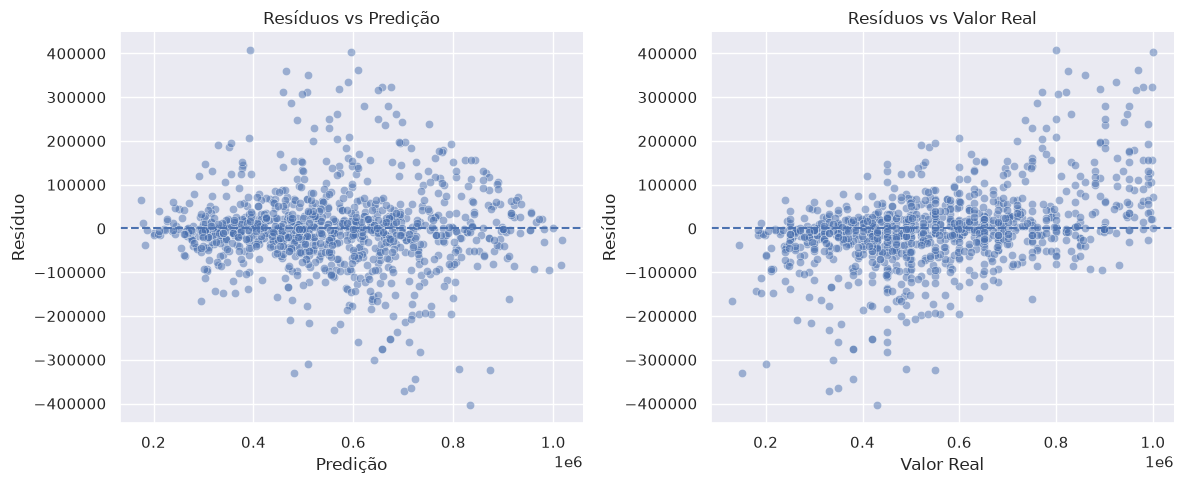

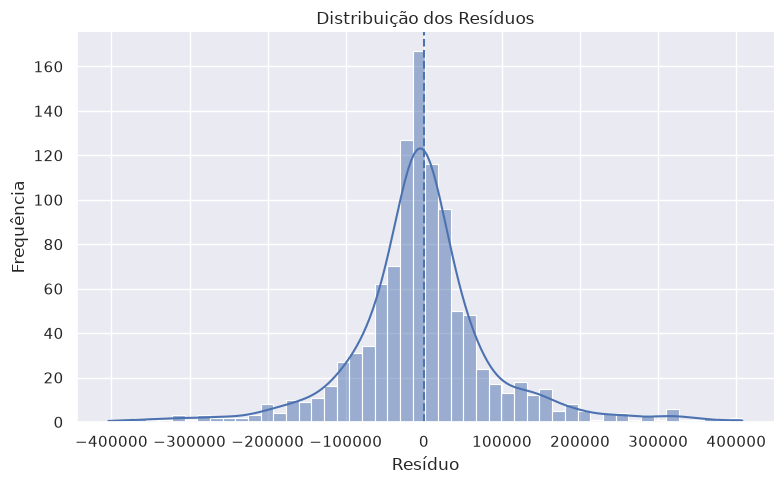

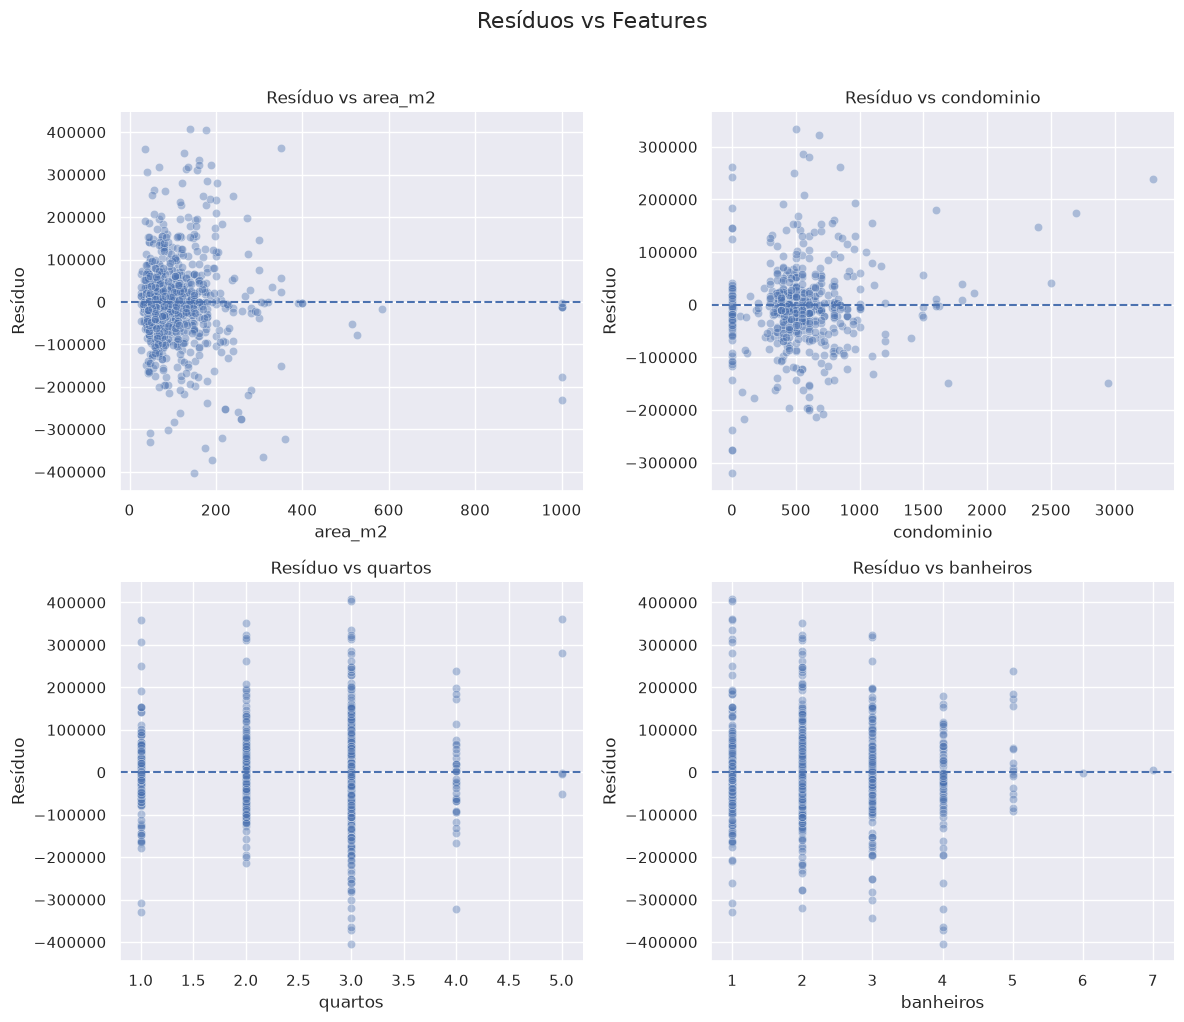

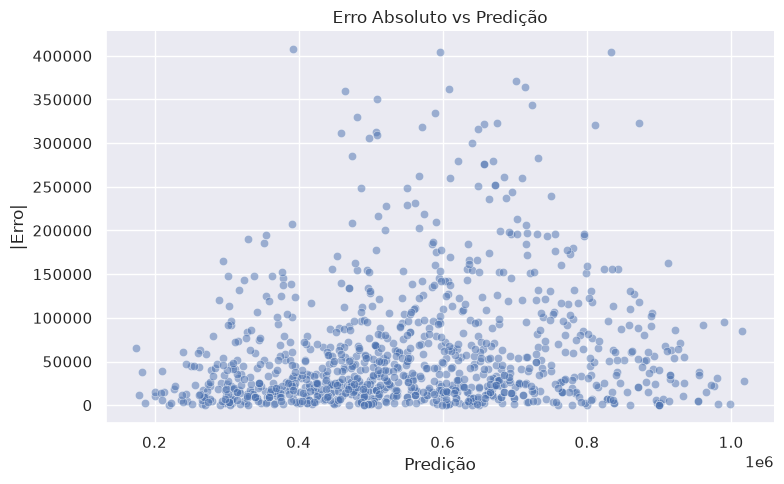


=== Erro Relativo Absoluto ===
count      1050.0
mean     0.118398
std      0.163148
min      0.000021
25%      0.028501
50%      0.066131
75%      0.148066
max      2.168073
Name: absolute_relative_error, dtype: Float64

=== 20 Maiores Erros Absolutos ===
      tipo_imovel  condominio  area_m2  quartos  banheiros  vagas  piscina  espaco_gourmet  academia  spa_massagem  espaco_lazer  area_trabalho  espaco_infantil  area_esportiva  portaria  seguranca  servicos_garagem  acessibilidade   pets  varanda  area_verde  espaco_natural  acabamento_premium  moveis_embutidos  layout_premium  cozinha  servicos  conforto_interno  mobiliado  casa_inteligente  servicos_conectividade  infra_energetica  infra_hidrica  servicos_sustentaveis   latitude  longitude  distancia_flamboyant_shopping_km  distancia_goiania_shopping_km  distancia_passeio_das_aguas_km  distancia_setor_central_km  distancia_setor_bueno_km  distancia_setor_marista_km  distancia_jardim_goias_km  distancia_aeroporto_km    faixa_area 

In [13]:
linear_regression_error_df = utils.get_residual_analysis(
    get_pipeline=get_xgboost_pipeline,
    study=study,
    X_train=X_train_normal,
    y_train=y_train_normal,
    X_test=X_test_normal,
    y_test=y_test_normal
)